## Comparative analysis of results in Bologna:

### Land Surface Temperature predicted from High resolution data and open Global datasets

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# inputs
lst_observed = '../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LST_clipped_celsius.tif'
lst_predicted_hr_data = '../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/LST_predicted_RF.tif'
lst_predicted_global_data = '../../datos-notebooks/2.global-data-bologna/LST-prediction/LST_predicted_RF.tif'
lst_predicted_from_hr_global_data = '../../datos-notebooks/2.global-data-bologna/LST-prediction/LST_predicted_RF_fromHRdata.tif'

#output
out_diff = '../../datos-notebooks/4.comparative-analysis/LST_difference_bologna.tif'

In [3]:
def quantify(o, p, nodata):
    # Mask valid pixels
    mask = np.isfinite(o) & np.isfinite(p)
    if nodata is not None:
        mask &= (o != nodata)

    o = o[mask]
    p = p[mask]

    # Metrics rounded 
    print(f"Bias: {np.mean(p-o):.3f}")
    print(f"MAE: {np.mean(np.abs(p-o)):.3f}")
    print(f"RMSE: {np.sqrt(np.mean((p-o)**2)):.3f}")
    print(f"Pearson r: {np.corrcoef(o,p)[0,1]:.3f}")

#### predicted vs observed

In [14]:
# prediction: model trained with HR data, applied with HR data
print("---- model trained with HR data vs observed LST----")
with rasterio.open(lst_observed) as s1, rasterio.open(lst_predicted_hr_data) as s2:
    quantify(s1.read(1).astype("float32"),
             s2.read(1).astype("float32"),
             s1.nodata)
    
# prediction: model trained with HR data, applied with global datasets
print("---- model trained with HR data, applied with global datasets vs observed LST ----")
with rasterio.open(lst_observed) as s1, rasterio.open(lst_predicted_from_hr_global_data) as s2:
    quantify(s1.read(1).astype("float32"),
             s2.read(1).astype("float32"),
             s1.nodata)
    
# prediction: model trained with global datasets, applied with global datasets
print("---- model trained with global datasets vs observed LST ----")
with rasterio.open(lst_observed) as s1, rasterio.open(lst_predicted_global_data) as s2:
    quantify(s1.read(1).astype("float32"),
             s2.read(1).astype("float32"),
             s1.nodata)



---- model trained with HR data vs observed LST----
Bias: 0.001
MAE: 0.689
RMSE: 0.971
Pearson r: 0.953
---- model trained with HR data, applied with global datasets vs observed LST ----
Bias: 0.263
MAE: 1.267
RMSE: 1.716
Pearson r: 0.849
---- model trained with global datasets vs observed LST ----
Bias: -0.002
MAE: 0.686
RMSE: 0.950
Pearson r: 0.955


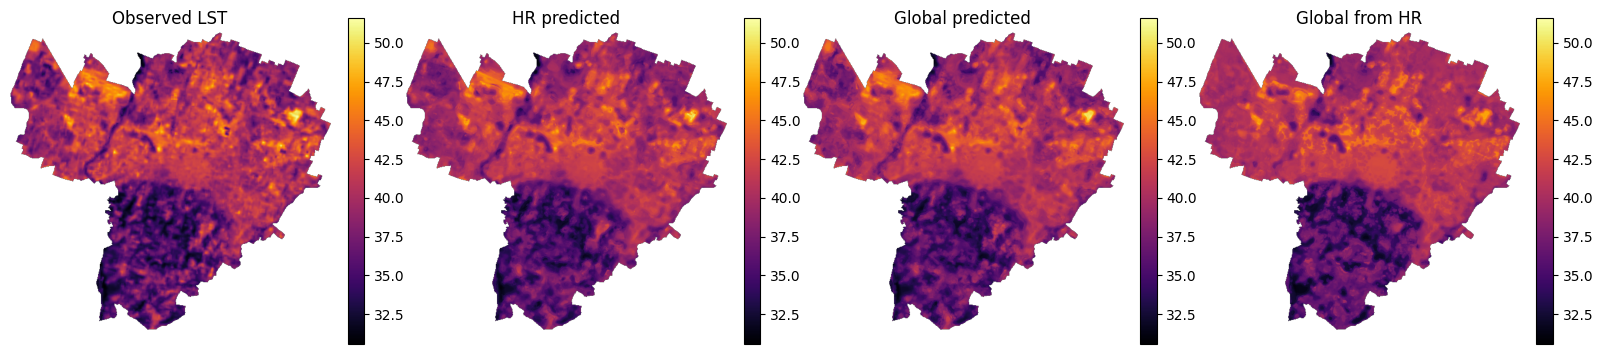

In [5]:
with rasterio.open(lst_observed) as obs, rasterio.open(lst_predicted_hr_data) as hr, rasterio.open(lst_predicted_global_data) as glob, rasterio.open(lst_predicted_from_hr_global_data) as glob_from_hr:
    xmin, ymin, xmax, ymax = obs.bounds
    obs_data = obs.read(1).astype("float32")
    hr_data = hr.read(1).astype("float32")  
    glob_data = glob.read(1).astype("float32")
    glob_from_hr_data = glob_from_hr.read(1).astype("float32")
    
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Observed
im0 = axes[0].imshow(obs_data, cmap="inferno", vmin=np.nanmin(obs_data), vmax=np.nanmax(obs_data))
axes[0].set_title("Observed LST")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# HR predicted
im1 = axes[1].imshow(hr_data, cmap="inferno", vmin=np.nanmin(obs_data), vmax=np.nanmax(obs_data))
axes[1].set_title("HR predicted")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Global predicted
im2 = axes[2].imshow(glob_data, cmap="inferno", vmin=np.nanmin(obs_data), vmax=np.nanmax(obs_data))
axes[2].set_title("Global predicted")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# Global from HR predicted
im3 = axes[3].imshow(glob_from_hr_data, cmap="inferno", vmin=np.nanmin(obs_data), vmax=np.nanmax(obs_data))
axes[3].set_title("Global from HR")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()




#### differences between predictions trained with HR data: applied with HR data and with global datasets

In [10]:
os.makedirs(os.path.dirname(out_diff), exist_ok=True)

with rasterio.open(lst_predicted_hr_data) as src1, rasterio.open(lst_predicted_global_data) as src2:

    # Read bands as float 
    r1 = src1.read(1).astype("float32")
    r2 = src2.read(1).astype("float32")

    # Difference 
    diff = r1 - r2

    # Save output raster 
    profile = src1.profile
    profile.update(dtype="float32")

    with rasterio.open(out_diff, "w", **profile) as dst:
        dst.write(diff.astype("float32"), 1)
        
    print("Saved in:", out_diff)

Saved in: ../../datos-notebooks/4.comparative-analysis/LST_difference_bologna.tif


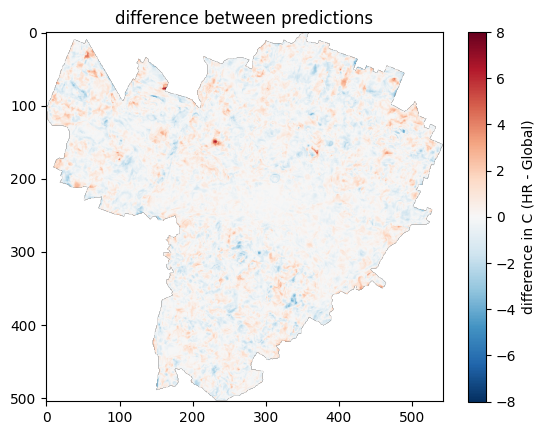

In [11]:
# Plot result 
with rasterio.open(lst_predicted_hr_data) as src:
    xmin, ymin, xmax, ymax = src.bounds

plt.figure()
plt.title("difference between predictions")
plt.imshow(diff, cmap='RdBu_r', vmin=-8, vmax=8)
plt.colorbar(label="difference in C (HR - Global)")
plt.show()


In [12]:
# Quantify raster differences
with rasterio.open(out_diff) as srcd:
    diff = srcd.read(1).astype("float32")
    nodata = srcd.nodata

# Build valid mask
mask = np.isfinite(diff)
if nodata is not None:
    mask &= (diff != nodata)

d = diff[mask]

# Basic stats 
print(f"Mean diff: {np.mean(d):.3f}")
print(f"Median diff: {np.median(d):.3f}")
print(f"Std diff: {np.std(d):.3f}")

# Error-like metrics 
mae = float(np.mean(np.abs(d)))
rmse = float(np.sqrt(np.mean(d**2)))
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Mean diff: 0.003
Median diff: -0.007
Std diff: 0.695
MAE: 0.491
RMSE: 0.695


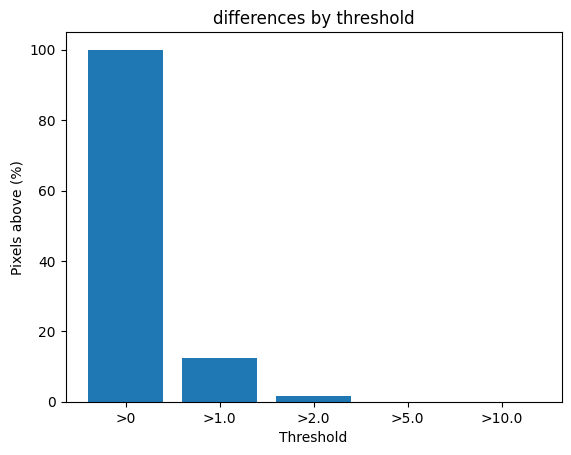

In [13]:
# Plot bar chart with threshold labels
thresholds = [0,1.0, 2.0, 5.0, 10.0]
fractions = [float(np.mean(np.abs(d) > thr)) * 100 for thr in thresholds]

plt.figure()
plt.title("differences by threshold")

bars = plt.bar(range(len(thresholds)), fractions) # Create bars

plt.xlabel("Threshold")
plt.ylabel("Pixels above (%)")
plt.xticks(range(len(thresholds)), [f">{t}" for t in thresholds])
plt.show()
